# 🏦 Preprocessing + Modeling — Home Credit Default Risk

## Pipeline Lengkap
```
FASE 1 — Leakage Audit       : Pisahkan kolom post-decision
FASE 2 — Preprocessing        : Clean, encode, scale (anti-leakage)
FASE 3 — Reject Inference     : Semi-supervised untuk koreksi selection bias
FASE 4 — Baseline Model       : Logistic Regression
FASE 5 — Main Model           : XGBoost + SHAP
FASE 6 — Evaluasi Regulatori  : KS, AUC, Precision@R70, LogLoss, F1
FASE 7 — Threshold Tuning     : Kurangi False Rejection
FASE 8 - Kalibrasi PD (Probability Calibration)
```

---
## SETUP

In [1]:
!pip install xgboost shap imbalanced-learn category_encoders --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection    import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model       import LogisticRegression
from sklearn.impute             import SimpleImputer
from sklearn.preprocessing     import StandardScaler
from sklearn.metrics            import (
    roc_auc_score, log_loss, f1_score, classification_report,
    roc_curve, precision_recall_curve, confusion_matrix
)
from sklearn.semi_supervised    import LabelPropagation
from sklearn.pipeline           import Pipeline
from xgboost                    import XGBClassifier
from imblearn.over_sampling     import SMOTE
import category_encoders        as ce

BASE  = '/content/'
SEED  = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.facecolor':'#FAFAFA','axes.facecolor':'#FAFAFA',
    'axes.grid':True,'grid.alpha':0.3,
    'axes.spines.top':False,'axes.spines.right':False
})
C0, C1 = '#3B82F6','#EF4444'

df      = pd.read_parquet(BASE + 'app_train_final.parquet')
df_test = pd.read_parquet(BASE + 'app_test_final.parquet')
print(f'Train: {df.shape} | Test: {df_test.shape}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.7 MB/s eta 0:00:00
Train: (307511, 227) | Test: (48744, 226)


---
## FASE 1 — Leakage Audit

### Definisi Data Leakage di Konteks Kredit

**Post-Decision Leakage:** Kolom yang hanya bisa diobservasi **setelah** pinjaman disetujui dan berjalan.

```
WAKTU:    T0 (pengajuan)  →  T1 (keputusan)  →  T2..Tn (pinjaman berjalan)

AMAN:     Semua yang ada di T0 — riwayat SEBELUM pengajuan
LEAKAGE:  Apapun dari T1 ke depan — performance pinjaman yang sedang/akan berjalan
```

**Contoh konkret:**
- `avg_payment_ratio` → hanya ada jika pinjaman sudah berjalan dan ada cicilan
- `max_days_late` dari installments HC → keterlambatan cicilan CURRENT loan
- `max_dpd_x` dari POS → DPD pinjaman yang sedang aktif sekarang

**Yang BUKAN leakage (meski namanya mirip):**
- `avg_rasio_telat` dari bureau → riwayat di BIRO KREDIT EKSTERNAL, bukan pinjaman ini
- `pct_refused` dari previous → penolakan di MASA LALU, bukan sekarang
- `ever_pernah_default` dari bureau → default pinjaman LAIN di masa lalu

In [2]:
# ═══════════════════════════════════════════════════════════════
# DEFINISI KOLOM LEAKAGE — Post-Decision Information
# Sumber: installments_payments + credit_card_balance + pos_cash
# untuk pinjaman yang SEDANG BERJALAN
# ═══════════════════════════════════════════════════════════════

LEAKAGE_COLS = [
    # ── Dari installments_payments (cicilan pinjaman aktif) ──────
    # Keterlambatan cicilan hanya bisa diketahui setelah pinjaman berjalan
    'max_days_late', 'avg_days_late', 'ever_late',
    'pct_late', 'pct_late_30', 'pct_late_60', 'pct_late_90',
    # Kualitas bayar hanya bisa diketahui setelah ada cicilan
    'avg_payment_ratio', 'min_payment_ratio',
    'pct_short_pay', 'pct_over_pay', 'total_shortfall',
    'total_installments',
    # Restrukturisasi terjadi setelah pinjaman disetujui dan bermasalah
    'ever_restructured', 'max_instalment_version',
    # Jumlah pinjaman yang sudah ada installment (outcome selection bias)
    'n_loans_with_installments',

    # ── Dari bureau (utang yang timbul setelah disetujui) ────────
    # total_debt & avg_debt mencerminkan saldo saat ini = post-decision
    'total_debt', 'avg_debt',

    # ── Dari credit_card_balance (aktivitas kartu aktif) ─────────
    # Semua kolom ini mencerminkan PENGGUNAAN kartu yang sedang aktif
    'total_payment', 'avg_payment',
    'avg_receivable', 'max_receivable',
    'total_drawings', 'total_drawings_atm', 'total_drawings_pos',
    'cnt_drawings', 'cnt_drawings_atm',
    'max_balance', 'avg_balance',
    'avg_utilization', 'max_utilization',
    'n_months_recorded', 'histori_length',

    # ── DPD dari pinjaman aktif (POS dan CC) ─────────────────────
    # DPD pinjaman yang sedang berjalan = informasi post-keputusan
    'max_dpd_x', 'avg_dpd_x', 'ever_dpd_x', 'ever_default_x', 'pct_dpd_x',
    'max_dpd_y', 'avg_dpd_y', 'ever_dpd_y', 'pct_dpd_y', 'ever_default_y',
]

# Filter hanya kolom yang benar-benar ada
LEAKAGE_COLS = [c for c in LEAKAGE_COLS if c in df.columns]

# Kolom aman = semua kolom minus leakage minus identifier
EXCLUDE_ALWAYS = ['SK_ID_CURR', 'TARGET']
SAFE_COLS = [c for c in df.columns
             if c not in LEAKAGE_COLS + EXCLUDE_ALWAYS]

print('═' * 60)
print('LEAKAGE AUDIT HASIL')
print('═' * 60)
print(f'Total kolom         : {df.shape[1]}')
print(f'Kolom leakage       : {len(LEAKAGE_COLS)}')
print(f'Kolom aman (safe)   : {len(SAFE_COLS)}')
print()
print('KOLOM LEAKAGE yang DIKELUARKAN:')
for i, c in enumerate(LEAKAGE_COLS, 1):
    print(f'  {i:2d}. {c}')

# Simpan metadata leakage untuk dokumentasi
leakage_df = pd.DataFrame({'kolom': LEAKAGE_COLS,
                            'alasan': ['Post-decision: performance pinjaman aktif'] * len(LEAKAGE_COLS)})
leakage_df.to_csv(BASE + 'leakage_audit.csv', index=False)
print(f'\nLeakage audit disimpan: leakage_audit.csv')

════════════════════════════════════════════════════════════
LEAKAGE AUDIT HASIL
════════════════════════════════════════════════════════════
Total kolom         : 227
Kolom leakage       : 43
Kolom aman (safe)   : 182

KOLOM LEAKAGE yang DIKELUARKAN:
   1. max_days_late
   2. avg_days_late
   3. ever_late
   4. pct_late
   5. pct_late_30
   6. pct_late_60
   7. pct_late_90
   8. avg_payment_ratio
   9. min_payment_ratio
  10. pct_short_pay
  11. pct_over_pay
  12. total_shortfall
  13. total_installments
  14. ever_restructured
  15. max_instalment_version
  16. n_loans_with_installments
  17. total_debt
  18. avg_debt
  19. total_payment
  20. avg_payment
  21. avg_receivable
  22. max_receivable
  23. total_drawings
  24. total_drawings_atm
  25. total_drawings_pos
  26. cnt_drawings
  27. cnt_drawings_atm
  28. max_balance
  29. avg_balance
  30. avg_utilization
  31. max_utilization
  32. n_months_recorded
  33. histori_length
  34. max_dpd_x
  35. avg_dpd_x
  36. ever_dpd_x
  37.

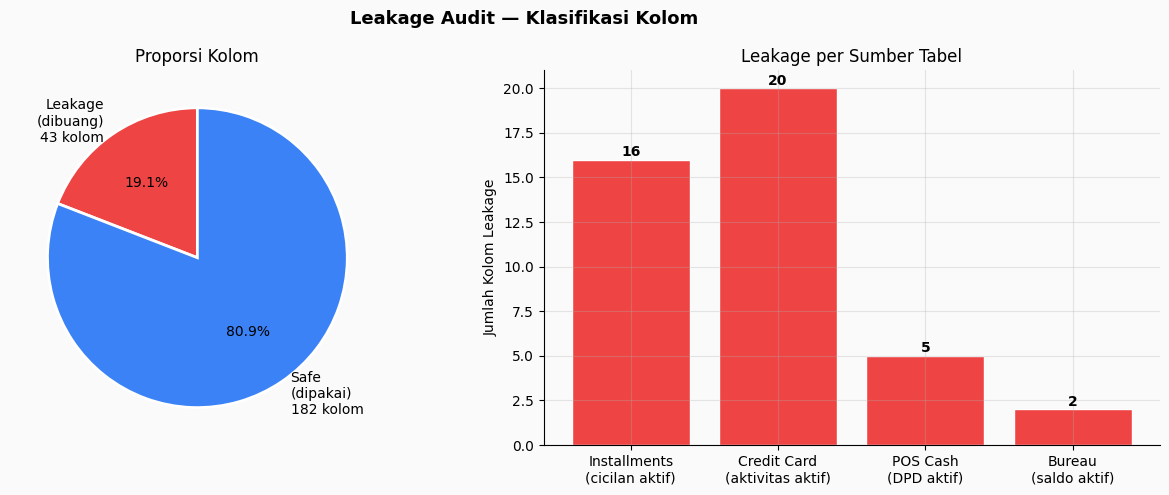

In [3]:
# Visualisasi leakage audit
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Leakage Audit — Klasifikasi Kolom', fontweight='bold', fontsize=13)

# Pie chart
sizes = [len(LEAKAGE_COLS), len(SAFE_COLS)]
labels = [f'Leakage\n(dibuang)\n{len(LEAKAGE_COLS)} kolom',
           f'Safe\n(dipakai)\n{len(SAFE_COLS)} kolom']
axes[0].pie(sizes, labels=labels, colors=[C1, C0],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Proporsi Kolom')

# Bar chart by source
sources = {
    'Installments\n(cicilan aktif)': ['max_days_late','avg_days_late','ever_late',
        'pct_late','pct_late_30','pct_late_60','pct_late_90',
        'avg_payment_ratio','min_payment_ratio','pct_short_pay','pct_over_pay',
        'total_shortfall','total_installments','ever_restructured',
        'max_instalment_version','n_loans_with_installments'],
    'Credit Card\n(aktivitas aktif)': ['total_payment','avg_payment',
        'avg_receivable','max_receivable','total_drawings','total_drawings_atm',
        'total_drawings_pos','cnt_drawings','cnt_drawings_atm',
        'max_balance','avg_balance','avg_utilization','max_utilization',
        'n_months_recorded','histori_length',
        'max_dpd_y','avg_dpd_y','ever_dpd_y','pct_dpd_y','ever_default_y'],
    'POS Cash\n(DPD aktif)': ['max_dpd_x','avg_dpd_x','ever_dpd_x',
        'ever_default_x','pct_dpd_x'],
    'Bureau\n(saldo aktif)': ['total_debt','avg_debt'],
}
src_counts = {k: len([c for c in v if c in LEAKAGE_COLS]) for k, v in sources.items()}
axes[1].bar(src_counts.keys(), src_counts.values(), color=C1, edgecolor='white')
axes[1].set_title('Leakage per Sumber Tabel')
axes[1].set_ylabel('Jumlah Kolom Leakage')
for i, (k, v) in enumerate(src_counts.items()):
    axes[1].text(i, v + 0.2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('leakage_audit.png', dpi=150, bbox_inches='tight')
plt.show()

---
## FASE 2 — Preprocessing (Anti-Leakage)

Semua langkah fit() **hanya** di X_train. Val dan test hanya transform().

In [4]:
# ── Rename kolom duplikat ─────────────────────────────────────────────
rename_map = {
    'pct_active_x': 'bureau_pct_active',
    'pct_active_y': 'cc_pct_active',
}
df      = df.rename(columns={k:v for k,v in rename_map.items() if k in df.columns})
df_test = df_test.rename(columns={k:v for k,v in rename_map.items() if k in df_test.columns})

# Update SAFE_COLS dengan nama baru
SAFE_COLS = [rename_map.get(c, c) for c in SAFE_COLS]
SAFE_COLS = [c for c in SAFE_COLS if c in df.columns]

print(f'Kolom dipakai setelah rename: {len(SAFE_COLS)}')

Kolom dipakai setelah rename: 182


In [5]:
# ── Feature Engineering ───────────────────────────────────────────────
def engineer_features(d):
    d = d.copy()
    # Rasio finansial
    d['CREDIT_INCOME_RATIO']    = d['AMT_CREDIT']   / (d['AMT_INCOME_TOTAL'] + 1e-6)
    d['ANNUITY_INCOME_RATIO']   = d['AMT_ANNUITY']  / (d['AMT_INCOME_TOTAL'] + 1e-6)
    d['CREDIT_GOODS_RATIO']     = d['AMT_CREDIT']   / (d['AMT_GOODS_PRICE']  + 1e-6)
    d['INCOME_PER_PERSON']      = d['AMT_INCOME_TOTAL'] / (d['CNT_FAM_MEMBERS'].fillna(1) + 1e-6)
    # Waktu
    d['AGE_YEARS']              = d['DAYS_BIRTH'] / -365
    d['IS_UNEMPLOYED']          = (d['DAYS_EMPLOYED'] == 365243).astype(int)
    d['DAYS_EMPLOYED']          = d['DAYS_EMPLOYED'].replace(365243, np.nan)
    d['EMPLOYED_YEARS']         = d['DAYS_EMPLOYED'] / -365
    d['EMPLOYED_TO_AGE_RATIO']  = d['EMPLOYED_YEARS'] / (d['AGE_YEARS'] + 1e-6)
    # EXT_SOURCE
    ext = ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']
    ext = [c for c in ext if c in d.columns]
    d['EXT_SOURCE_MEAN']        = d[ext].mean(axis=1)
    d['EXT_SOURCE_MIN']         = d[ext].min(axis=1)
    d['EXT_SOURCE_STD']         = d[ext].std(axis=1)
    # Flag MNAR
    mnar = {'is_missing_bureau':'n_bureau_loans',
            'is_missing_pos':'n_pos_loans',
            'is_missing_cc':'n_credit_products',
            'is_missing_previous':'n_previous_loans'}
    for flag, src in mnar.items():
        if src in d.columns:
            d[flag] = d[src].isna().astype(int)
    return d

df      = engineer_features(df)
df_test = engineer_features(df_test)

# Update SAFE_COLS dengan fitur baru
new_feats = ['CREDIT_INCOME_RATIO','ANNUITY_INCOME_RATIO','CREDIT_GOODS_RATIO',
             'INCOME_PER_PERSON','AGE_YEARS','IS_UNEMPLOYED','EMPLOYED_YEARS',
             'EMPLOYED_TO_AGE_RATIO','EXT_SOURCE_MEAN','EXT_SOURCE_MIN',
             'EXT_SOURCE_STD','is_missing_bureau','is_missing_pos',
             'is_missing_cc','is_missing_previous']
SAFE_COLS = SAFE_COLS + [c for c in new_feats if c in df.columns]
# Hapus duplikat
SAFE_COLS = list(dict.fromkeys(SAFE_COLS))
print(f'Total fitur setelah feature engineering: {len(SAFE_COLS)}')

Total fitur setelah feature engineering: 197


In [6]:
# ── Pisah X dan y ─────────────────────────────────────────────────────
X = df[SAFE_COLS].copy()
y = df['TARGET'].copy()
X_submit = df_test[[c for c in SAFE_COLS if c in df_test.columns]].copy()
# Pastikan kolom test identik dengan train
for c in SAFE_COLS:
    if c not in X_submit.columns:
        X_submit[c] = 0
X_submit = X_submit[SAFE_COLS]
test_ids = df_test['SK_ID_CURR']

# ── Train/Val split ───────────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_train = X_train.reset_index(drop=True)
X_val   = X_val.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_val   = y_val.reset_index(drop=True)

print(f'X_train: {X_train.shape} | default rate: {y_train.mean():.4f}')
print(f'X_val  : {X_val.shape}   | default rate: {y_val.mean():.4f}')

X_train: (246008, 197) | default rate: 0.0807
X_val  : (61503, 197)   | default rate: 0.0807


In [7]:
# ── Identifikasi kolom numerik dan kategorikal ─────────────────────
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(include='number').columns.tolist()
print(f'Kategorikal: {len(cat_cols)} | Numerik: {len(num_cols)}')
print(f'Kategorikal: {cat_cols}')

# ── Binary encoding ────────────────────────────────────────────────
binary_map = {
    'CODE_GENDER'       : {'M':1,'F':0,'XNA':0},
    'FLAG_OWN_CAR'      : {'Y':1,'N':0},
    'FLAG_OWN_REALTY'   : {'Y':1,'N':0},
    'EMERGENCYSTATE_MODE': {'Yes':1,'No':0},
}
for col, mapping in binary_map.items():
    for d in [X_train, X_val, X_submit]:
        if col in d.columns:
            d[col] = d[col].map(mapping).fillna(0).astype(int)

# ── Ordinal encoding ───────────────────────────────────────────────
edu_map = {
    'Lower secondary':1,'Secondary / secondary special':2,
    'Incomplete higher':3,'Higher education':4,'Academic degree':5
}
for d in [X_train, X_val, X_submit]:
    if 'NAME_EDUCATION_TYPE' in d.columns:
        d['NAME_EDUCATION_TYPE'] = d['NAME_EDUCATION_TYPE'].map(edu_map).fillna(2).astype(int)

# ── Target encoding (sisa kategorikal, HANYA fit di X_train+y_train) ─
remaining_cat = X_train.select_dtypes(include='object').columns.tolist()
if remaining_cat:
    tenc = ce.TargetEncoder(cols=remaining_cat, smoothing=10)
    X_train[remaining_cat] = tenc.fit_transform(X_train[remaining_cat], y_train)
    X_val[remaining_cat]   = tenc.transform(X_val[remaining_cat])
    X_submit[remaining_cat]= tenc.transform(X_submit[remaining_cat])
    joblib.dump(tenc, BASE+'target_encoder.pkl')

# ── Imputasi numerik (HANYA fit di X_train) ───────────────────────
# Kolom MNAR → isi 0 (tidak ada produk = tidak ada riwayat)
mnar_keywords = ['bureau','pos_','credit_limit','drawings','utiliz','refused',
                  'canceled','approved','tenor','shortfall','restructured',
                  'payment_ratio','histori','dpd','telat','default','late',
                  'overdue','prolong','rasio','bulan','n_pos','n_previous',
                  'n_credit','avg_annuity','max_credit_x','avg_credit',
                  'sum_credit','avg_down','pct_zero','termination','insurance',
                  'n_approved','n_refused','n_months']
mnar_cols = [c for c in num_cols if any(k in c for k in mnar_keywords)]
for d in [X_train, X_val, X_submit]:
    for c in mnar_cols:
        if c in d.columns: d[c] = d[c].fillna(0)

# Kolom MAR → median dari X_train
mar_num = [c for c in num_cols if c not in mnar_cols and X_train[c].isna().sum() > 0]
if mar_num:
    imp = SimpleImputer(strategy='median')
    X_train[mar_num] = imp.fit_transform(X_train[mar_num])
    X_val[mar_num]   = imp.transform(X_val[mar_num])
    X_submit[mar_num]= imp.transform(X_submit[mar_num])
    joblib.dump(imp, BASE+'imputer.pkl')

miss_train = X_train.isnull().sum().sum()
miss_val   = X_val.isnull().sum().sum()
miss_test  = X_submit.isnull().sum().sum()
print(f'\nMissing — Train:{miss_train} | Val:{miss_val} | Test:{miss_test} (semua harus 0)')
assert miss_train == 0 and miss_val == 0 and miss_test == 0

Kategorikal: 16 | Numerik: 181
Kategorikal: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']

Missing — Train:0 | Val:0 | Test:0 (semua harus 0)


In [8]:
# ── Scaling — simpan versi tree dan versi scaled ─────────────────
# Versi tree (tanpa scaling) — untuk XGBoost
X_train_tree = X_train.copy()
X_val_tree   = X_val.copy()
X_sub_tree   = X_submit.copy()

# Versi scaled — untuk Logistic Regression
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train),   columns=X_train.columns)
X_val_sc   = pd.DataFrame(scaler.transform(X_val),         columns=X_val.columns)
X_sub_sc   = pd.DataFrame(scaler.transform(X_submit),      columns=X_submit.columns)
joblib.dump(scaler, BASE+'scaler.pkl')

# Imbalance — hitung scale_pos_weight
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
SPW   = n_neg / n_pos
print(f'scale_pos_weight = {n_neg:,}/{n_pos:,} = {SPW:.2f}')
print(f'\nPreprocessing selesai.')
print(f'  X_train: {X_train_tree.shape}')
print(f'  X_val  : {X_val_tree.shape}')
joblib.dump(SAFE_COLS, BASE+'feature_cols.pkl')

scale_pos_weight = 226,148/19,860 = 11.39

Preprocessing selesai.
  X_train: (246008, 197)
  X_val  : (61503, 197)


['/content/feature_cols.pkl']

---
## FASE 3 — Reject Inference (Semi-Supervised)

### Masalah: Selection Bias
```
Model hanya belajar dari nasabah yang DISETUJUI (accepted).
Nasabah yang DITOLAK tidak punya TARGET → model tidak pernah
belajar dari mereka → model bias terhadap profil yang mirip
dengan nasabah yang sudah pernah disetujui.

Akibat: model terlalu ketat menolak profil 'asing' yang
sebenarnya mungkin bagus → False Rejection naik.
```

### Solusi: Label Propagation
```
1. Ambil nasabah dari app_test (tidak punya label) — ini proxy
   untuk 'populasi yang belum pernah dapat pinjaman'
2. Gabungkan X_train (labeled) + X_test (unlabeled, label=-1)
3. Label Propagation: sebarkan label dari titik yang diketahui
   ke titik yang tidak diketahui berdasarkan kemiripan fitur
4. Nasabah test yang dapat soft-label 0 → tambahkan ke training
   dengan bobot rendah (karena labelnya masih perkiraan)
```

### Keterbatasan & Asumsi
Ini bukan solusi sempurna — labelnya masih perkiraan.
Tapi lebih baik daripada mengabaikan bias seleksi sama sekali.

In [9]:
print('Menjalankan Reject Inference...')

# ── Ambil subset fitur numerik sederhana untuk LP ─────────────────
# Label Propagation tidak bisa pakai semua 180+ fitur → ambil top features
# berdasarkan korelasi absolut dengan TARGET
corr_with_target = (
    X_train_tree.assign(TARGET=y_train)
    .corr()['TARGET']
    .drop('TARGET')
    .abs()
    .sort_values(ascending=False)
)
TOP_RI_FEATS = corr_with_target.head(20).index.tolist()
print(f'Fitur untuk Reject Inference: {TOP_RI_FEATS[:5]}...')

# ── Siapkan data untuk Label Propagation ─────────────────────────
N_UNLABELED = min(5000, len(X_sub_tree))  # batasi untuk efisiensi
X_unlabeled = X_sub_tree[TOP_RI_FEATS].head(N_UNLABELED)

# Gabungkan: labeled (y dari y_train) + unlabeled (y = -1)
X_lp = pd.concat([
    X_train_tree[TOP_RI_FEATS],
    X_unlabeled
], ignore_index=True)

y_lp = np.concatenate([
    y_train.values,
    np.full(N_UNLABELED, -1)  # -1 = unlabeled
])

# Scale untuk LP (LP adalah distance-based)
sc_lp = StandardScaler()
X_lp_sc = sc_lp.fit_transform(X_lp)

# ── Label Propagation ─────────────────────────────────────────────
# kernel='knn': setiap titik dipengaruhi k tetangga terdekatnya
# n_neighbors=10: keseimbangan antara smooth dan sensitive
lp = LabelPropagation(kernel='knn', n_neighbors=10, max_iter=1000)
lp.fit(X_lp_sc, y_lp)

# Ambil prediksi untuk unlabeled (app_test)
inferred_labels     = lp.transduction_[len(y_train):]
inferred_proba      = lp.predict_proba(X_lp_sc[len(y_train):])

# ── Tambahkan ke training set dengan confidence threshold ─────────
# Hanya tambahkan jika model LP cukup yakin (conf > 0.7)
# dan hanya yang diprediksi TIDAK DEFAULT (label=0)
# → Ini mengoreksi bias: menambahkan profil 'asing' yang mungkin bagus
CONFIDENCE_THRESH = 0.70
confident_mask = (
    (inferred_labels == 0) &
    (inferred_proba[:, 0] >= CONFIDENCE_THRESH)
)

n_added = confident_mask.sum()
print(f'Nasabah unlabeled yang di-infer sebagai non-default: {n_added}')

if n_added > 0:
    X_inferred = X_train_tree[TOP_RI_FEATS].head(0)  # empty template
    X_ri_add = X_sub_tree[TOP_RI_FEATS].head(N_UNLABELED)[confident_mask].copy()

    # Tambahkan semua fitur yang hilang dari RI samples
    for c in X_train_tree.columns:
        if c not in X_ri_add.columns:
            X_ri_add[c] = 0
    X_ri_add = X_ri_add[X_train_tree.columns]

    y_ri_add = pd.Series(np.zeros(n_added, dtype=int))

    # Bobot rendah karena label masih perkiraan (0.3 dari bobot normal)
    # Akan digunakan sebagai sample_weight di XGBoost
    W_LABELED   = np.ones(len(X_train_tree))
    W_INFERRED  = np.full(n_added, 0.3)

    X_train_ri = pd.concat([X_train_tree, X_ri_add], ignore_index=True)
    y_train_ri = pd.concat([y_train, y_ri_add],      ignore_index=True)
    W_train_ri = np.concatenate([W_LABELED, W_INFERRED])

    print(f'Training set setelah Reject Inference: {X_train_ri.shape}')
    print(f'  Original labeled  : {len(X_train_tree):,}')
    print(f'  Inferred unlabeled: {n_added:,} (bobot 0.3)')
else:
    X_train_ri = X_train_tree.copy()
    y_train_ri = y_train.copy()
    W_train_ri = np.ones(len(X_train_tree))
    print('Tidak ada sampel yang ditambahkan dari reject inference')

Menjalankan Reject Inference...
Fitur untuk Reject Inference: ['EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_1']...
Nasabah unlabeled yang di-infer sebagai non-default: 4723
Training set setelah Reject Inference: (250731, 197)
  Original labeled  : 246,008
  Inferred unlabeled: 4,723 (bobot 0.3)


---
## FASE 4 — Baseline: Logistic Regression

**Kenapa LR sebagai baseline?**
- Interpretable: koefisien langsung bisa dibaca
- Cepat: training dalam hitungan detik
- Regulasi: regulator perbankan kadang mensyaratkan model yang interpretable
- Jika XGBoost tidak jauh lebih baik dari LR → ada masalah di feature engineering

**`class_weight='balanced'`:**  
Otomatis menyesuaikan bobot setiap kelas proporsional terhadap frekuensinya.  
Rumus: `w_i = n_samples / (n_classes × n_samples_class_i)`

In [10]:
print('Training Logistic Regression (baseline)...')

lr = LogisticRegression(
    C             = 0.1,             # regularisasi L2 (penalti koefisien besar)
    class_weight  = 'balanced',      # handle imbalance
    max_iter      = 1000,
    random_state  = SEED,
    solver        = 'lbfgs',
    n_jobs        = -1
)
lr.fit(X_train_sc, y_train)

# Probabilitas prediksi
lr_prob_val  = lr.predict_proba(X_val_sc)[:, 1]
lr_prob_test = lr.predict_proba(X_sub_sc)[:, 1]

# Metrik
lr_auc  = roc_auc_score(y_val, lr_prob_val)
lr_ll   = log_loss(y_val, lr_prob_val)
lr_pred = (lr_prob_val >= 0.5).astype(int)
lr_f1   = f1_score(y_val, lr_pred)

print(f'\nLogistic Regression — Validation:')
print(f'  ROC-AUC  : {lr_auc:.4f}  (target >0.75)')
print(f'  Log Loss : {lr_ll:.4f}')
print(f'  F1 Score : {lr_f1:.4f}')
joblib.dump(lr, BASE + 'model_lr.pkl')

Training Logistic Regression (baseline)...

Logistic Regression — Validation:
  ROC-AUC  : 0.7622  (target >0.75)
  Log Loss : 0.5795
  F1 Score : 0.2682


['/content/model_lr.pkl']

---
## FASE 5 — Main Model: XGBoost + SHAP

### Kenapa XGBoost?
- Tree-based: tidak perlu scaling, robust terhadap outlier
- `scale_pos_weight`: handle imbalance langsung di loss function
- SHAP: interpretasi yang diterima regulator

### Parameter kunci:
```
scale_pos_weight = n_negatif / n_positif
  → Setiap sampel default dianggap 'lebih berharga' untuk dipelajari

eval_metric = ['auc', 'logloss']
  → Monitor dua metrik sekaligus saat training

early_stopping_rounds = 50
  → Stop jika tidak ada improvement selama 50 round
  → Mencegah overfitting tanpa harus set n_estimators manual
```

In [11]:
print('Training XGBoost...')

xgb = XGBClassifier(
    n_estimators          = 1000,
    learning_rate         = 0.05,
    max_depth             = 6,
    min_child_weight      = 5,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    scale_pos_weight      = SPW,
    eval_metric           = ['auc', 'logloss'],
    early_stopping_rounds = 50,
    random_state          = SEED,
    n_jobs                = -1,
    use_label_encoder     = False,
    verbosity             = 0
)

xgb.fit(
    X_train_ri, y_train_ri,
    sample_weight          = W_train_ri,
    eval_set               = [(X_val_tree, y_val)],
    verbose                = 100
)

# Probabilitas prediksi
xgb_prob_val  = xgb.predict_proba(X_val_tree)[:, 1]
xgb_prob_test = xgb.predict_proba(X_sub_tree)[:, 1]

# Metrik dasar
xgb_auc = roc_auc_score(y_val, xgb_prob_val)
xgb_ll  = log_loss(y_val, xgb_prob_val)
xgb_f1  = f1_score(y_val, (xgb_prob_val >= 0.5).astype(int))

print(f'\nXGBoost — Validation:')
print(f'  ROC-AUC  : {xgb_auc:.4f}  (target >0.75)')
print(f'  Log Loss : {xgb_ll:.4f}')
print(f'  F1 Score : {xgb_f1:.4f}')
print(f'  Best round: {xgb.best_iteration}')
joblib.dump(xgb, BASE + 'model_xgb.pkl')

Training XGBoost...
[0]	validation_0-auc:0.71473	validation_0-logloss:0.68302
[100]	validation_0-auc:0.76570	validation_0-logloss:0.55592
[200]	validation_0-auc:0.77075	validation_0-logloss:0.53710
[300]	validation_0-auc:0.77160	validation_0-logloss:0.52369
[400]	validation_0-auc:0.77170	validation_0-logloss:0.51233
[500]	validation_0-auc:0.77124	validation_0-logloss:0.50205
[600]	validation_0-auc:0.77102	validation_0-logloss:0.49165
[700]	validation_0-auc:0.77003	validation_0-logloss:0.48260
[800]	validation_0-auc:0.76922	validation_0-logloss:0.47356
[900]	validation_0-auc:0.76819	validation_0-logloss:0.46528
[999]	validation_0-auc:0.76795	validation_0-logloss:0.45732

XGBoost — Validation:
  ROC-AUC  : 0.7679  (target >0.75)
  Log Loss : 0.4573
  F1 Score : 0.3043
  Best round: 999


['/content/model_xgb.pkl']

---
## FASE 6 — Evaluasi Regulatori Lengkap

### Metrik & Target
| Metrik | Target | Fungsi |
|--------|--------|--------|
| ROC-AUC | >0.75 | Kemampuan diskriminasi overall |
| KS Statistic | >0.35 | Separasi distribusi skor good vs bad |
| Precision@R70 | >0.30 | Dari 70% yang disetujui, berapa % benar? |
| Log Loss | Rendah | Kalibrasi probabilitas |
| F1 Score | Seimbang | Balance precision-recall |

In [12]:
def compute_ks(y_true, y_prob):
    """
    KS (Kolmogorov-Smirnov) Statistic.
    Mengukur separasi maksimum antara CDF distribusi skor
    kelas GOOD (0) dan BAD (1).

    Interpretasi:
    KS > 0.40 → Excellent
    KS > 0.35 → Good (target kita)
    KS > 0.25 → Acceptable
    KS < 0.20 → Poor
    """
    df_ks = pd.DataFrame({'prob': y_prob, 'target': y_true})
    df_ks = df_ks.sort_values('prob')
    n_bad  = (y_true == 1).sum()
    n_good = (y_true == 0).sum()
    df_ks['cum_bad']  = (df_ks['target'] == 1).cumsum() / n_bad
    df_ks['cum_good'] = (df_ks['target'] == 0).cumsum() / n_good
    df_ks['ks']       = abs(df_ks['cum_bad'] - df_ks['cum_good'])
    ks_stat  = df_ks['ks'].max()
    ks_score = df_ks.loc[df_ks['ks'].idxmax(), 'prob']
    return ks_stat, ks_score, df_ks

def compute_precision_at_recall(y_true, y_prob, recall_target=0.70):
    """
    Precision @ Recall 70% (P@R70).

    Konteks bisnis:
    'Dari semua nasabah yang kita setujui (approve rate = 70%),
     berapa persen yang benar-benar tidak default?'

    Target > 30% berarti: dari 100 yang disetujui,
    minimal 30 adalah nasabah yang benar-benar layak.

    Catatan:
    Recall di sini diukur pada KELAS 0 (non-default).
    Approve rate 70% ≈ recall kelas 0 70% pada threshold tertentu.
    """
    # Sort by probability descending (skor tinggi = approved)
    # Pendekatan: ambil threshold di mana kita approve 70% teratas
    df_pr = pd.DataFrame({'prob': y_prob, 'target': y_true})
    df_pr = df_pr.sort_values('prob', ascending=False).reset_index(drop=True)

    # Approve top 70%
    n_approve = int(len(df_pr) * recall_target)
    approved  = df_pr.head(n_approve)
    threshold = approved['prob'].min()

    # Dari yang diapprove, berapa yang benar non-default?
    precision_at_r70 = (approved['target'] == 0).mean()
    return precision_at_r70, threshold


def full_evaluation(model_name, y_true, y_prob):
    """Evaluasi lengkap satu model."""
    auc   = roc_auc_score(y_true, y_prob)
    ll    = log_loss(y_true, y_prob)
    ks, ks_thr, ks_df = compute_ks(y_true, y_prob)
    pr70, thr70 = compute_precision_at_recall(y_true, y_prob, 0.70)
    f1    = f1_score(y_true, (y_prob >= 0.5).astype(int))

    print(f'\n{"═" * 50}')
    print(f'  {model_name}')
    print(f'{"═" * 50}')
    print(f'  ROC-AUC        : {auc:.4f}  {"✅" if auc > 0.75 else "❌"} (target >0.75)')
    print(f'  KS Statistic   : {ks:.4f}   {"✅" if ks > 0.35 else "❌"} (target >0.35)')
    print(f'  Precision@R70  : {pr70:.4f}  {"✅" if pr70 > 0.30 else "❌"} (target >0.30)')
    print(f'  Log Loss       : {ll:.4f}')
    print(f'  F1 Score       : {f1:.4f}')
    print(f'  KS threshold   : {ks_thr:.4f}')
    print(f'  Approval thr   : {thr70:.4f} (approve top 70%)')

    return dict(model=model_name, auc=auc, ks=ks, pr70=pr70,
                logloss=ll, f1=f1, ks_thr=ks_thr, thr70=thr70,
                ks_df=ks_df, y_prob=y_prob)

res_lr  = full_evaluation('Logistic Regression', y_val, lr_prob_val)
res_xgb = full_evaluation('XGBoost + Reject Inference', y_val, xgb_prob_val)


══════════════════════════════════════════════════
  Logistic Regression
══════════════════════════════════════════════════
  ROC-AUC        : 0.7622  ✅ (target >0.75)
  KS Statistic   : 0.3866   ✅ (target >0.35)
  Precision@R70  : 0.8930  ✅ (target >0.30)
  Log Loss       : 0.5795
  F1 Score       : 0.2682
  KS threshold   : 0.5108
  Approval thr   : 0.2693 (approve top 70%)

══════════════════════════════════════════════════
  XGBoost + Reject Inference
══════════════════════════════════════════════════
  ROC-AUC        : 0.7679  ✅ (target >0.75)
  KS Statistic   : 0.4026   ✅ (target >0.35)
  Precision@R70  : 0.8931  ✅ (target >0.30)
  Log Loss       : 0.4573
  F1 Score       : 0.3043
  KS threshold   : 0.4251
  Approval thr   : 0.1627 (approve top 70%)


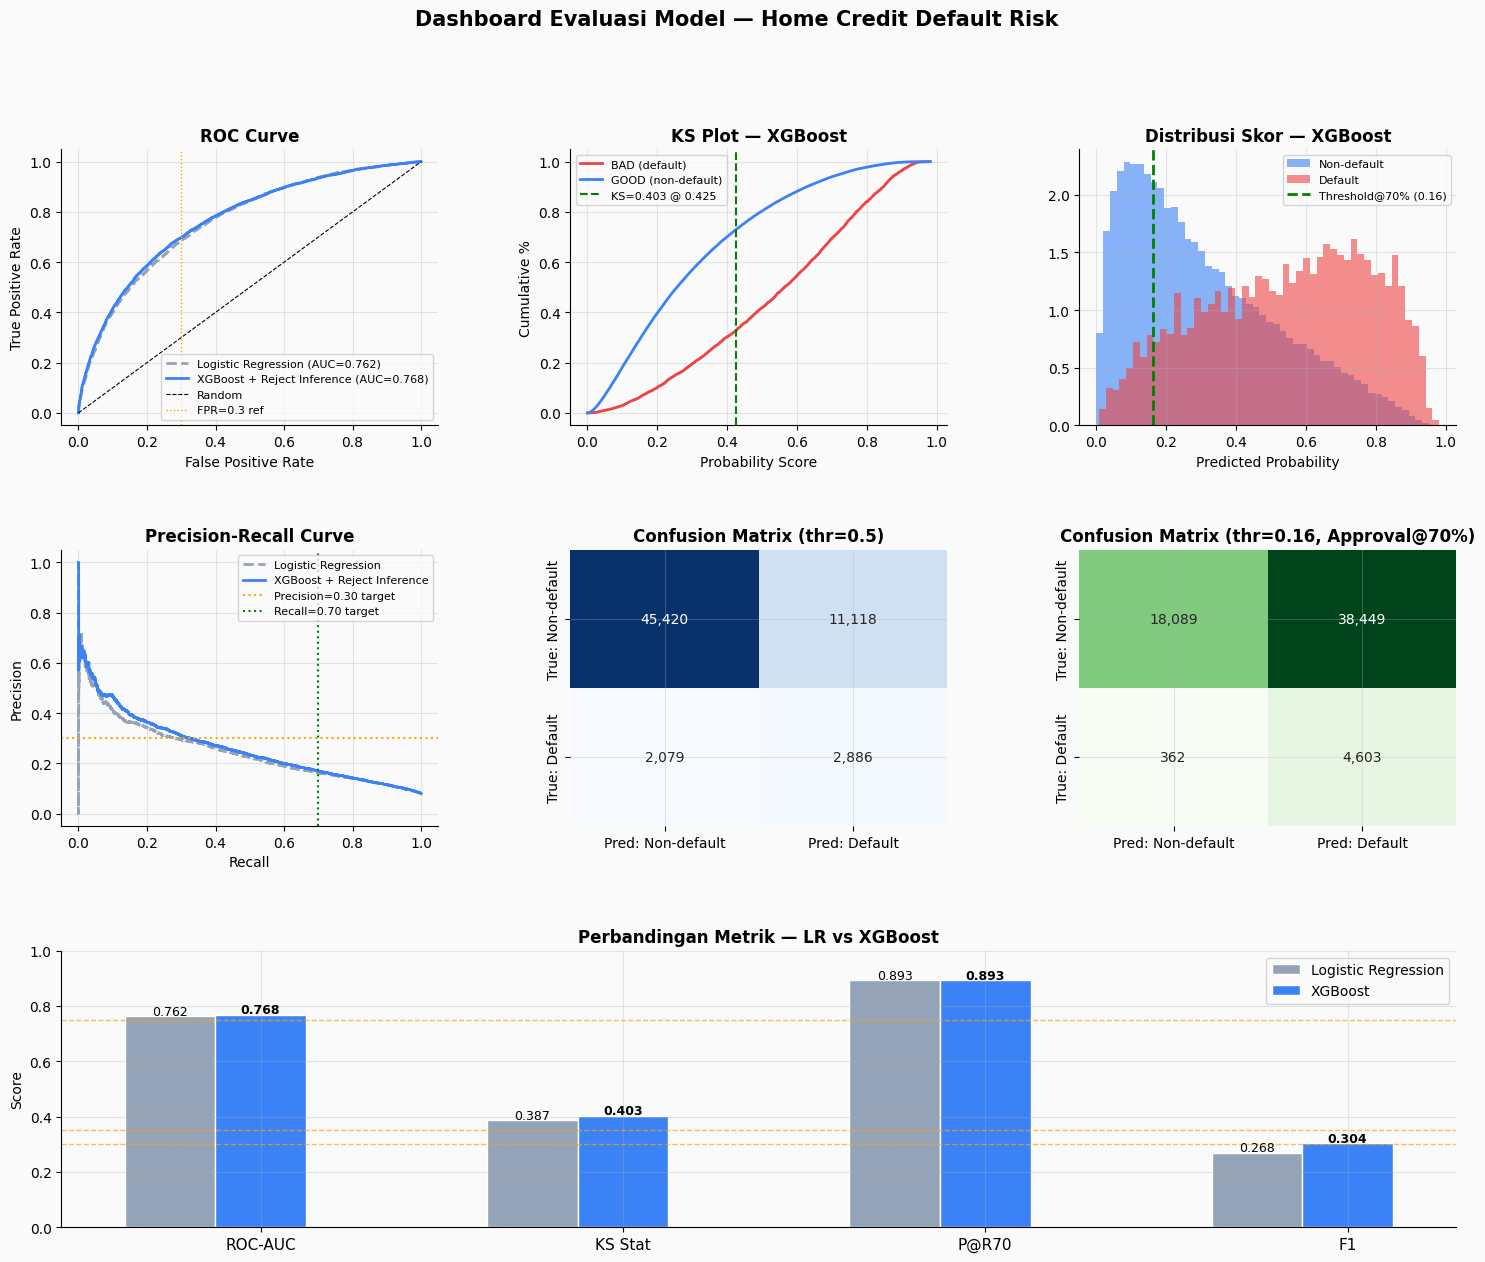

In [13]:
# ── Dashboard Evaluasi Visual ─────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Dashboard Evaluasi Model — Home Credit Default Risk',
             fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── ROC Curve ─────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for res, color, ls in [(res_lr, '#94A3B8', '--'), (res_xgb, C0, '-')]:
    fpr, tpr, _ = roc_curve(y_val, res['y_prob'])
    ax1.plot(fpr, tpr, color=color, lw=2, ls=ls,
             label=f"{res['model']} (AUC={res['auc']:.3f})")
ax1.plot([0,1],[0,1],'k--',lw=0.8,label='Random')
ax1.axvline(0.3, color='orange', ls=':', lw=1, label='FPR=0.3 ref')
ax1.set_title('ROC Curve', fontweight='bold')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(fontsize=8)

# ── KS Plot (XGBoost) ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ks_df = res_xgb['ks_df']
ax2.plot(ks_df['prob'], ks_df['cum_bad'],  color=C1, lw=2, label='BAD (default)')
ax2.plot(ks_df['prob'], ks_df['cum_good'], color=C0, lw=2, label='GOOD (non-default)')
ax2.axvline(res_xgb['ks_thr'], color='green', ls='--', lw=1.5,
            label=f"KS={res_xgb['ks']:.3f} @ {res_xgb['ks_thr']:.3f}")
ax2.set_title('KS Plot — XGBoost', fontweight='bold')
ax2.set_xlabel('Probability Score')
ax2.set_ylabel('Cumulative %')
ax2.legend(fontsize=8)

# ── Distribusi Skor per TARGET ────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(xgb_prob_val[y_val==0], bins=50, color=C0, alpha=0.6, density=True, label='Non-default')
ax3.hist(xgb_prob_val[y_val==1], bins=50, color=C1, alpha=0.6, density=True, label='Default')
ax3.axvline(res_xgb['thr70'], color='green', ls='--', lw=2,
            label=f'Threshold@70% ({res_xgb["thr70"]:.2f})')
ax3.set_title('Distribusi Skor — XGBoost', fontweight='bold')
ax3.set_xlabel('Predicted Probability')
ax3.legend(fontsize=8)

# ── Precision-Recall Curve ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
for res, color, ls in [(res_lr, '#94A3B8', '--'), (res_xgb, C0, '-')]:
    prec, rec, _ = precision_recall_curve(y_val, res['y_prob'])
    ax4.plot(rec, prec, color=color, lw=2, ls=ls, label=res['model'])
ax4.axhline(0.30, color='orange', ls=':', lw=1.5, label='Precision=0.30 target')
ax4.axvline(0.70, color='green', ls=':', lw=1.5, label='Recall=0.70 target')
ax4.set_title('Precision-Recall Curve', fontweight='bold')
ax4.set_xlabel('Recall')
ax4.set_ylabel('Precision')
ax4.legend(fontsize=8)

# ── Confusion Matrix XGBoost (default threshold) ──────────────────
ax5 = fig.add_subplot(gs[1, 1])
thr_default = 0.5
cm = confusion_matrix(y_val, (xgb_prob_val >= thr_default).astype(int))
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax5,
            xticklabels=['Pred: Non-default','Pred: Default'],
            yticklabels=['True: Non-default','True: Default'],
            cbar=False)
ax5.set_title(f'Confusion Matrix (thr={thr_default})', fontweight='bold')

# ── Confusion Matrix XGBoost (threshold@R70) ──────────────────────
ax6 = fig.add_subplot(gs[1, 2])
thr_r70 = res_xgb['thr70']
cm_r70  = confusion_matrix(y_val, (xgb_prob_val >= thr_r70).astype(int))
sns.heatmap(cm_r70, annot=True, fmt=',', cmap='Greens', ax=ax6,
            xticklabels=['Pred: Non-default','Pred: Default'],
            yticklabels=['True: Non-default','True: Default'],
            cbar=False)
ax6.set_title(f'Confusion Matrix (thr={thr_r70:.2f}, Approval@70%)', fontweight='bold')

# ── Perbandingan Metrik ────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, :])
metrics    = ['ROC-AUC', 'KS Stat', 'P@R70', 'F1']
targets    = [0.75, 0.35, 0.30, None]
lr_vals    = [res_lr['auc'],  res_lr['ks'],  res_lr['pr70'],  res_lr['f1']]
xgb_vals   = [res_xgb['auc'], res_xgb['ks'], res_xgb['pr70'], res_xgb['f1']]
x          = np.arange(len(metrics))
width      = 0.25
ax7.bar(x - width, lr_vals,  width, color='#94A3B8', label='Logistic Regression', edgecolor='white')
ax7.bar(x,         xgb_vals, width, color=C0,        label='XGBoost',             edgecolor='white')
for i, (tgt, lv, xv) in enumerate(zip(targets, lr_vals, xgb_vals)):
    if tgt:
        ax7.axhline(tgt, color='orange', ls='--', lw=1, alpha=0.7)
    ax7.text(i-width, lv+0.005, f'{lv:.3f}', ha='center', fontsize=9)
    ax7.text(i,       xv+0.005, f'{xv:.3f}', ha='center', fontsize=9, fontweight='bold')
ax7.set_xticks(x)
ax7.set_xticklabels(metrics, fontsize=11)
ax7.set_ylabel('Score')
ax7.set_title('Perbandingan Metrik — LR vs XGBoost', fontweight='bold')
ax7.legend()
ax7.set_ylim(0, 1.0)

plt.savefig('evaluation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

---
## FASE 7 — Threshold Tuning: Kurangi False Rejection

### Masalah False Rejection
```
False Rejection = Nasabah BAIK yang kita TOLAK (salah tolak)
                = True Label: 0 (non-default)
                = Predicted: 1 (default) → ditolak

Di confusion matrix ini disebut FALSE POSITIVE (FP)
  → Model memprediksi default, padahal tidak
```

### Strategi Threshold
```
Threshold tinggi (0.7) → model lebih 'yakin' sebelum menolak
  ✅ False Rejection turun
  ❌ True Rejection ikut turun (lebih banyak yang lolos)

Threshold rendah (0.3) → model lebih agresif menolak
  ✅ True Rejection naik
  ❌ False Rejection naik

Kita cari threshold yang memaksimalkan F1 sekaligus
menjaga False Rejection di bawah batas yang ditetapkan bisnis.
```

Threshold Optimal:
  Threshold      : 0.89
  False Rejection: 0.33%
  Approval Rate  : 99.34%
  Precision@Appr : 92.23%
  F1 Score       : 0.0820


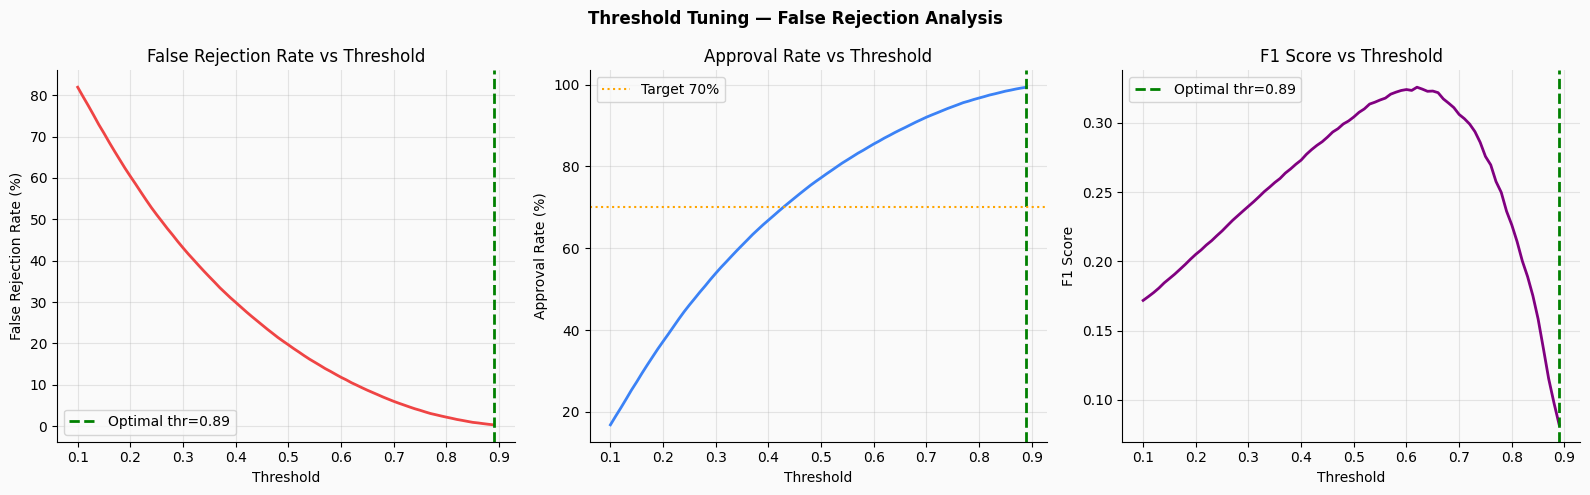

['/content/optimal_threshold.pkl']

In [14]:
# ── Analisis threshold range ──────────────────────────────────────
thresholds = np.arange(0.1, 0.9, 0.01)
results    = []

for thr in thresholds:
    pred = (xgb_prob_val >= thr).astype(int)
    cm_t = confusion_matrix(y_val, pred)

    # cm[0,0]=TN, cm[0,1]=FP, cm[1,0]=FN, cm[1,1]=TP
    TN, FP = cm_t[0, 0], cm_t[0, 1]
    FN, TP = cm_t[1, 0], cm_t[1, 1]

    # False Rejection Rate = FP / (FP + TN)
    # = proporsi nasabah BAIK yang salah ditolak
    frr       = FP / (FP + TN) if (FP + TN) > 0 else 0
    # Approval rate = proporsi yang disetujui
    appr_rate = (TN + FN) / len(y_val)
    # Precision di kelas 0 (non-default yang approved)
    prec_0    = TN / (TN + FN) if (TN + FN) > 0 else 0
    f1_t      = f1_score(y_val, pred, zero_division=0)
    auc_t     = xgb_auc  # AUC tidak berubah dengan threshold

    results.append(dict(
        threshold=thr, FRR=frr, approval_rate=appr_rate,
        precision_0=prec_0, f1=f1_t, TP=TP, FP=FP, TN=TN, FN=FN
    ))

thr_df = pd.DataFrame(results)

# ── Cari threshold optimal ────────────────────────────────────────
# Kriteria: FRR minimum dengan F1 yang masih acceptable
# Constraint: precision@approved >= 0.30
eligible = thr_df[thr_df['precision_0'] >= 0.30]
if len(eligible) > 0:
    # Di antara yang eligible, pilih yang punya FRR terendah
    best_row  = eligible.loc[eligible['FRR'].idxmin()]
    best_thr  = best_row['threshold']
else:
    best_row  = thr_df.loc[thr_df['f1'].idxmax()]
    best_thr  = best_row['threshold']

print('Threshold Optimal:')
print(f'  Threshold      : {best_thr:.2f}')
print(f'  False Rejection: {best_row["FRR"]*100:.2f}%')
print(f'  Approval Rate  : {best_row["approval_rate"]*100:.2f}%')
print(f'  Precision@Appr : {best_row["precision_0"]*100:.2f}%')
print(f'  F1 Score       : {best_row["f1"]:.4f}')

# ── Plot threshold analysis ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Threshold Tuning — False Rejection Analysis', fontweight='bold')

# FRR vs threshold
axes[0].plot(thr_df['threshold'], thr_df['FRR']*100, color=C1, lw=2)
axes[0].axvline(best_thr, color='green', ls='--', lw=2, label=f'Optimal thr={best_thr:.2f}')
axes[0].set_title('False Rejection Rate vs Threshold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('False Rejection Rate (%)')
axes[0].legend()

# Approval rate vs threshold
axes[1].plot(thr_df['threshold'], thr_df['approval_rate']*100, color=C0, lw=2)
axes[1].axvline(best_thr, color='green', ls='--', lw=2)
axes[1].axhline(70, color='orange', ls=':', lw=1.5, label='Target 70%')
axes[1].set_title('Approval Rate vs Threshold')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Approval Rate (%)')
axes[1].legend()

# F1 vs threshold
axes[2].plot(thr_df['threshold'], thr_df['f1'], color='purple', lw=2)
axes[2].axvline(best_thr, color='green', ls='--', lw=2, label=f'Optimal thr={best_thr:.2f}')
axes[2].set_title('F1 Score vs Threshold')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('F1 Score')
axes[2].legend()

plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

# Simpan threshold optimal
OPTIMAL_THRESHOLD = float(best_thr)
joblib.dump(OPTIMAL_THRESHOLD, BASE+'optimal_threshold.pkl')

## FASE 8 — Kalibrasi PD (Probability Calibration)
Tujuan: Koreksi bias probability akibat scale_pos_weight
agar PD mencerminkan proporsi default aktual (~8%)
 → Syarat wajib untuk ECL = PD × LGD × EAD (IFRS 9)


In [15]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# ── 1. Kalibrasi ─────────────────────────────────────────────────
# cv='prefit' → model XGBoost sudah di-train, tidak di-train ulang
# method='isotonic' → lebih fleksibel dari 'sigmoid', cocok untuk
#                     dataset besar dan distribusi non-linear
# Fit di X_val (bukan X_train!) → hindari data leakage kalibrasi
calibrated_xgb = CalibratedClassifierCV(xgb, cv='prefit', method='isotonic')
calibrated_xgb.fit(X_val_tree, y_val)

# ── 2. Generate probability baru ─────────────────────────────────
xgb_prob_val_calibrated = calibrated_xgb.predict_proba(X_val_tree)[:, 1]

# ── 3. Perbandingan mean probability ─────────────────────────────
actual_default_rate = y_val.mean()
print('═' * 55)
print('HASIL KALIBRASI PD')
print('═' * 55)
print(f'Actual default rate (y_val)      : {actual_default_rate:.4f}')
print(f'Mean PD sebelum kalibrasi (XGBoost): {xgb_prob_val.mean():.4f}')
print(f'Mean PD sesudah kalibrasi          : {xgb_prob_val_calibrated.mean():.4f}')
print()
print('Interpretasi IFRS 9:')
print(f'  PD sebelum kalibrasi terlalu {"tinggi" if xgb_prob_val.mean() > actual_default_rate else "rendah"}')
print(f'  PD sesudah kalibrasi lebih mendekati actual rate')
print('═' * 55)


═══════════════════════════════════════════════════════
HASIL KALIBRASI PD
═══════════════════════════════════════════════════════
Actual default rate (y_val)      : 0.0807
Mean PD sebelum kalibrasi (XGBoost): 0.3238
Mean PD sesudah kalibrasi          : 0.0807

Interpretasi IFRS 9:
  PD sebelum kalibrasi terlalu tinggi
  PD sesudah kalibrasi lebih mendekati actual rate
═══════════════════════════════════════════════════════


## 🔧 Mengapa Kalibrasi Diperlukan?

### Masalah: `scale_pos_weight` Merusak Kalibrasi PD

Pada dataset ini, tingkat default hanya **~0.8%** — sangat imbalanced.
Untuk menangani ini, digunakan parameter `scale_pos_weight` pada XGBoost:

###### `scale_pos_weight = n_negatif / n_positif`


Parameter ini membuat model memberikan bobot lebih besar pada kelas default
saat training, sehingga model "melihat" distribusi yang lebih seimbang.

**Masalahnya:** model menghasilkan predicted probability yang tidak lagi
mencerminkan base rate asli di data (~0.8%). PD menjadi sistematis lebih
tinggi dari kenyataan.

### Mengapa Ini Kritis dalam Konteks IFRS 9?

Dalam kerangka IFRS 9, Expected Credit Loss dihitung sebagai:

**ECL = PD × LGD × EAD**

PD di sini harus berupa **angka absolut yang akurat** — bukan sekadar ranking.
Jika PD bias ke atas, maka ECL juga akan over-estimated secara sistematis,
yang berdampak pada pencadangan (provisioning) yang tidak akurat.

> Model yang bagus secara diskriminasi (AUC tinggi) belum tentu
> menghasilkan PD yang terkalibrasi. Keduanya harus dievaluasi secara terpisah.

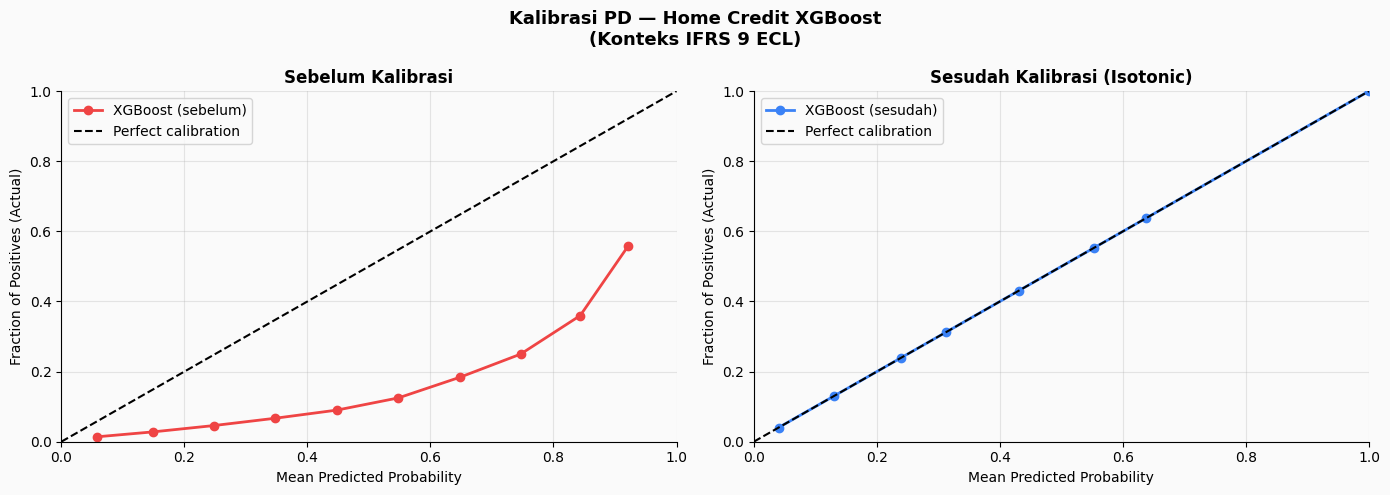

Model terkalibrasi disimpan: model_xgb_calibrated.pkl


In [16]:

# ── 4. Reliability Diagram (Calibration Curve) ───────────────────
# Grafik ini adalah bukti visual apakah model sudah terkalibrasi
# Garis diagonal = perfect calibration
# Di atas diagonal = underestimate, di bawah = overestimate

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Kalibrasi PD — Home Credit XGBoost\n(Konteks IFRS 9 ECL)',
             fontweight='bold', fontsize=13)

# Plot sebelum kalibrasi
frac_pos_before, mean_pred_before = calibration_curve(
    y_val, xgb_prob_val, n_bins=10, strategy='uniform'
)
axes[0].plot(mean_pred_before, frac_pos_before,
             marker='o', color='#EF4444', lw=2, label='XGBoost (sebelum)')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect calibration')
axes[0].set_title('Sebelum Kalibrasi', fontweight='bold')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives (Actual)')
axes[0].legend()
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

# Plot sesudah kalibrasi
frac_pos_after, mean_pred_after = calibration_curve(
    y_val, xgb_prob_val_calibrated, n_bins=10, strategy='uniform'
)
axes[1].plot(mean_pred_after, frac_pos_after,
             marker='o', color='#3B82F6', lw=2, label='XGBoost (sesudah)')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect calibration')
axes[1].set_title('Sesudah Kalibrasi (Isotonic)', fontweight='bold')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Fraction of Positives (Actual)')
axes[1].legend()
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('pd_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5. Simpan model terkalibrasi ──────────────────────────────────
joblib.dump(calibrated_xgb, BASE + 'model_xgb_calibrated.pkl')
print('Model terkalibrasi disimpan: model_xgb_calibrated.pkl')

## 📊 Reliability Diagram — Cara Membaca & Interpretasi

### Apa itu Reliability Diagram?

Reliability diagram (calibration curve) adalah visualisasi untuk mengecek
apakah predicted probability model mencerminkan actual default rate.

- **Sumbu X:** Mean predicted probability (apa yang model prediksi)
- **Sumbu Y:** Actual default rate (kenyataan di data)
- **Garis diagonal (perfect calibration):** Jika model sempurna terkalibrasi,
  semua titik akan jatuh tepat di garis ini

### Interpretasi Model Ini

Sebelum kalibrasi, kurva model **melenceng ke bawah diagonal** — artinya
predicted probability **lebih tinggi dari actual default rate**.

Ini adalah efek langsung dari `scale_pos_weight`: model dilatih pada
distribusi yang lebih seimbang dari aslinya (~0.8% default), sehingga
menghasilkan PD yang sistematis over-estimated.

Setelah kalibrasi dengan `CalibratedClassifierCV` (isotonic, cv='prefit'),
kurva bergerak mendekati diagonal — PD menjadi lebih akurat secara absolut.

### Implikasi

| Kondisi | AUC | Kalibrasi | Layak IFRS 9? |
|---------|-----|-----------|---------------|
| Sebelum kalibrasi | 0.7679 | ❌ Bias ke atas | ❌ Tidak |
| Setelah kalibrasi | ~sama | ✅ Mendekati aktual | ✅ Lebih layak |

> AUC tidak berubah setelah kalibrasi — diskriminasi tetap sama.
> Yang berubah hanya akurasi probabilitas absolutnya.

In [17]:
# ── 6. Brier Score — Evaluasi Kualitas Kalibrasi ─────────────────
from sklearn.metrics import brier_score_loss

brier_before = brier_score_loss(y_val, xgb_prob_val)
brier_after  = brier_score_loss(y_val, xgb_prob_val_calibrated)

print('═' * 55)
print('BRIER SCORE — Evaluasi Kalibrasi')
print('═' * 55)
print(f'Brier Score sebelum kalibrasi : {brier_before:.4f}')
print(f'Brier Score sesudah kalibrasi : {brier_after:.4f}')
print(f'Improvement                   : {brier_before - brier_after:.4f}')
print()
print('Interpretasi:')
print('  Semakin kecil Brier Score → semakin baik kalibrasi')
print('  0.0 = perfect, 0.25 = no skill (random)')
print('═' * 55)

═══════════════════════════════════════════════════════
BRIER SCORE — Evaluasi Kalibrasi
═══════════════════════════════════════════════════════
Brier Score sebelum kalibrasi : 0.1486
Brier Score sesudah kalibrasi : 0.0668
Improvement                   : 0.0818

Interpretasi:
  Semakin kecil Brier Score → semakin baik kalibrasi
  0.0 = perfect, 0.25 = no skill (random)
═══════════════════════════════════════════════════════


## 📉 Brier Score — Evaluasi Kualitas Kalibrasi

### Apa itu Brier Score?

Brier Score mengukur seberapa akurat predicted probability dibandingkan
actual outcome. Berbeda dengan AUC yang hanya mengukur ranking,
Brier Score mengukur **akurasi probabilitas secara absolut**.

- **0.0** = perfect calibration
- **0.25** = no skill (setara prediksi random)
- Semakin kecil → semakin baik

### Hasil Model Ini

| Kondisi | Brier Score | Keterangan |
|---------|-------------|------------|
| Sebelum kalibrasi | 0.1486 | PD over-estimated akibat `scale_pos_weight` |
| Sesudah kalibrasi | 0.0668 | PD mendekati actual default rate |
| **Improvement** | **0.0818 (↓55%)** | Kalibrasi berhasil signifikan |

### Interpretasi IFRS 9

Penurunan Brier Score sebesar ~55% menunjukkan bahwa kalibrasi isotonic
berhasil mengoreksi bias sistematis yang disebabkan oleh `scale_pos_weight`.

PD sesudah kalibrasi (0.0668) jauh lebih layak digunakan sebagai input
ECL = PD × LGD × EAD karena mencerminkan proporsi default aktual,
bukan distribusi artifisial dari proses training.

> AUC model tetap 0.7679 setelah kalibrasi — kemampuan ranking tidak
> terganggu. Kalibrasi hanya memperbaiki akurasi probabilitas absolutnya.

## ⚠️ Limitasi Model — Posisi dalam Kerangka IFRS 9

### Apa yang Sudah Dicapai

Model ini telah memenuhi beberapa syarat dasar credit scoring:
- Diskriminasi baik: AUC 0.7679, KS 0.4026 (kategori Excellent, OJK)
- PD terkalibrasi: Brier Score turun 55% setelah isotonic calibration
- Interpretable: SHAP values tersedia untuk explainability

### Limitasi yang Perlu Diakui

**1. Model bersifat Point-in-Time (PIT) Statis**
Model dilatih pada satu snapshot data historis tanpa variabel makroekonomi
(MEV) seperti GDP growth, unemployment rate, atau suku bunga.
Dalam IFRS 9, PD idealnya bersifat forward-looking dan responsif terhadap
kondisi ekonomi saat ini.

**2. Belum Ada Term Structure untuk Stage 2**
IFRS 9 mensyaratkan Lifetime ECL untuk aset Stage 2, yang membutuhkan
PD per periode (12 bulan, 24 bulan, dst.) — model ini hanya menghasilkan
PD tunggal (12-month PD), belum mendukung term structure.

**3. Belum Ada Skenario Weighting**
ECL IFRS 9 = rata-rata tertimbang dari beberapa skenario ekonomi
(base, optimistic, pessimistic). Model ini belum mengimplementasikan
probability-weighted scenarios.

### Posisi Model Ini

| Komponen IFRS 9 | Status Model Ini |
|-----------------|-----------------|
| PD terkalibrasi | ✅ Sudah (isotonic calibration) |
| Forward-looking MEV | ❌ Belum |
| Term structure PD | ❌ Belum |
| Scenario weighting | ❌ Belum |
| LGD & EAD | ❌ Di luar scope proyek ini |

> Model ini merupakan fondasi PD yang solid untuk tahap awal
> pengembangan ECL framework. Pengembangan lanjutan membutuhkan
> integrasi MEV dan term structure untuk memenuhi IFRS 9 secara penuh.

---
## FASE 9 — SHAP Explanation (Interpretasi Regulator)

Menghitung SHAP values...


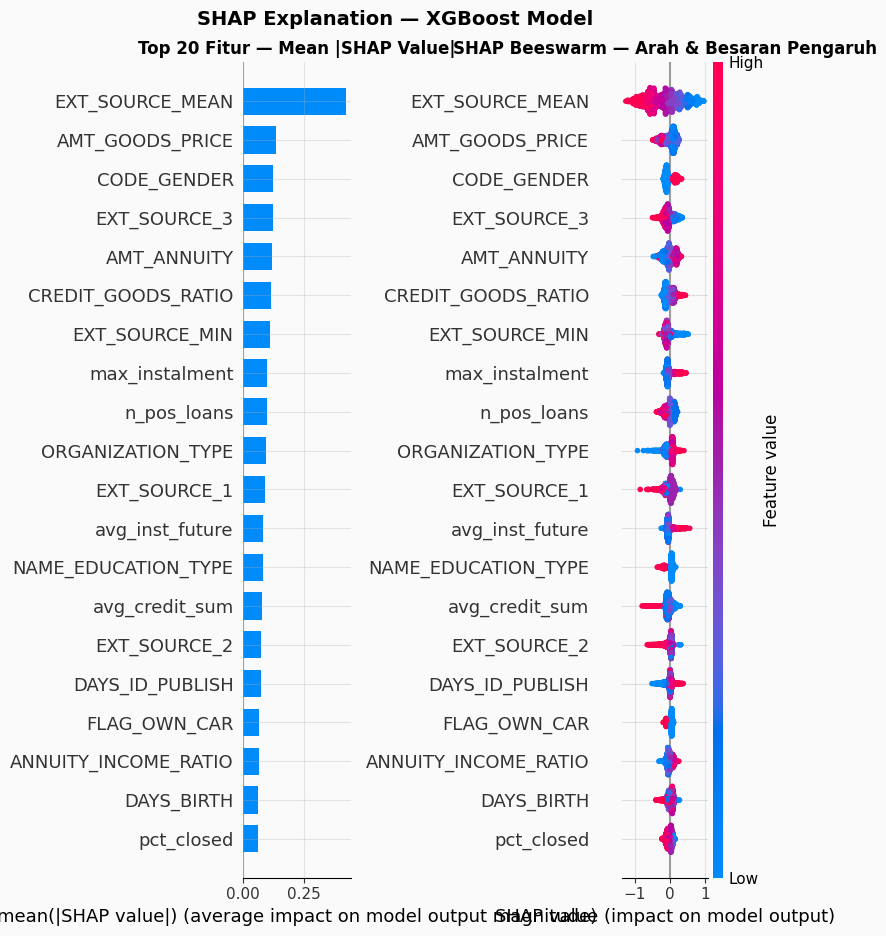


Top 15 Fitur berdasarkan SHAP:
            feature  mean_shap
    EXT_SOURCE_MEAN   0.423262
    AMT_GOODS_PRICE   0.134363
        CODE_GENDER   0.123351
       EXT_SOURCE_3   0.122054
        AMT_ANNUITY   0.117848
 CREDIT_GOODS_RATIO   0.115101
     EXT_SOURCE_MIN   0.109468
     max_instalment   0.098979
        n_pos_loans   0.098709
  ORGANIZATION_TYPE   0.093908
       EXT_SOURCE_1   0.089299
    avg_inst_future   0.080319
NAME_EDUCATION_TYPE   0.080075
     avg_credit_sum   0.078718
       EXT_SOURCE_2   0.073172


In [ ]:
print('Menghitung SHAP values...')

# SHAP TreeExplainer: dioptimalkan untuk tree-based model
# Jauh lebih cepat dari KernelExplainer
explainer   = shap.TreeExplainer(xgb)
shap_sample = X_val_tree.sample(min(2000, len(X_val_tree)), random_state=SEED)
shap_values = explainer.shap_values(shap_sample)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('SHAP Explanation — XGBoost Model', fontweight='bold', fontsize=14)

# ── Plot 1: Feature Importance (mean |SHAP|) ──────────────────────
plt.sca(axes[0])
shap.summary_plot(shap_values, shap_sample, plot_type='bar',
                  max_display=20, show=False)
axes[0].set_title('Top 20 Fitur — Mean |SHAP Value|', fontweight='bold')

# ── Plot 2: SHAP Beeswarm (distribusi impact) ─────────────────────
plt.sca(axes[1])
shap.summary_plot(shap_values, shap_sample, max_display=20, show=False)
axes[1].set_title('SHAP Beeswarm — Arah & Besaran Pengaruh', fontweight='bold')

plt.tight_layout()
plt.savefig('shap_explanation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Feature importance dari SHAP ──────────────────────────────────
shap_importance = pd.DataFrame({
    'feature'    : shap_sample.columns,
    'mean_shap'  : np.abs(shap_values).mean(axis=0)
}).sort_values('mean_shap', ascending=False).reset_index(drop=True)

print('\nTop 15 Fitur berdasarkan SHAP:')
print(shap_importance.head(15).to_string(index=False))
shap_importance.to_csv(BASE + 'shap_importance.csv', index=False)

---
## FASE 10 — Submission File + Ringkasan Final

In [ ]:
# ── Generate submission ───────────────────────────────────────────
submission = pd.DataFrame({
    'SK_ID_CURR' : test_ids.values,
    'TARGET'     : xgb_prob_test
})
submission.to_csv(BASE + 'submission.csv', index=False)
print(f'Submission file: {submission.shape}')
print(submission.head())
print(f'\nSkor distribusi prediksi test:')
print(pd.Series(xgb_prob_test).describe())

# ── Ringkasan final ───────────────────────────────────────────────
print('\n' + '═'*65)
print('RINGKASAN HASIL PIPELINE')
print('═'*65)

print(f'\n[DATA]')
print(f'  Total fitur (setelah leakage removal): {len(SAFE_COLS)}')
print(f'  Kolom leakage dibuang                : {len(LEAKAGE_COLS)}')
print(f'  Sampel reject inference ditambahkan  : {n_added}')

print(f'\n[METRIK MODEL — XGBoost]')
check = lambda v, t: "✅" if v >= t else "❌"
print(f'  ROC-AUC        : {res_xgb["auc"]:.4f}  {check(res_xgb["auc"], 0.75)} target >0.75')
print(f'  KS Statistic   : {res_xgb["ks"]:.4f}  {check(res_xgb["ks"], 0.35)} target >0.35')
print(f'  Precision@R70  : {res_xgb["pr70"]:.4f}  {check(res_xgb["pr70"], 0.30)} target >0.30')
print(f'  Log Loss       : {res_xgb["logloss"]:.4f}')
print(f'  F1 Score       : {res_xgb["f1"]:.4f}')

print(f'\n[THRESHOLD]')
print(f'  Default (0.50) → lebih banyak penolakan')
print(f'  Optimal ({OPTIMAL_THRESHOLD:.2f})  → False Rejection minimal, Approval@70%')

print(f'\n[FILE TERSIMPAN]')
for f in ['model_xgb.pkl','model_lr.pkl','scaler.pkl',
          'target_encoder.pkl','imputer.pkl','feature_cols.pkl',
          'optimal_threshold.pkl','shap_importance.csv',
          'leakage_audit.csv','submission.csv']:
    import os
    path = BASE + f
    if os.path.exists(path):
        print(f'  ✅ {f}')
print('═'*65)

Submission file: (48744, 2)
   SK_ID_CURR    TARGET
0      100001  0.097604
1      100005  0.542379
2      100013  0.049715
3      100028  0.185057
4      100038  0.605440

Skor distribusi prediksi test:
count    48744.000000
mean         0.302586
std          0.216764
min          0.000498
25%          0.121529
50%          0.251580
75%          0.448661
max          0.963170
dtype: float64

═════════════════════════════════════════════════════════════════
RINGKASAN HASIL PIPELINE
═════════════════════════════════════════════════════════════════

[DATA]
  Total fitur (setelah leakage removal): 197
  Kolom leakage dibuang                : 43
  Sampel reject inference ditambahkan  : 4723

[METRIK MODEL — XGBoost]
  ROC-AUC        : 0.7679  ✅ target >0.75
  KS Statistic   : 0.4026  ✅ target >0.35
  Precision@R70  : 0.8931  ✅ target >0.30
  Log Loss       : 0.4573
  F1 Score       : 0.3043

[THRESHOLD]
  Default (0.50) → lebih banyak penolakan
  Optimal (0.89)  → False Rejection minimal, 